<span style="font-size:75px;">🩺</span>
<span style="color:#bff793; font-size:75px; font-weight:bold;">
Diabetes Prediction
</span>

<p align="center">
  <img src="https://repository-images.githubusercontent.com/622616629/4c7a5f4d-8cbd-4c76-a816-38281082aae2" width="900" height="400"/>
</p>


**🎯 Project Idea**

The goal is to build an **end-to-end ML pipeline** that predicts whether a patient is diabetic based on diagnostic measurements.  
The project simulates a real-world workflow: 

data exploration → preprocessing → modeling → evaluation → deployment.  

---

**📊 About the Dataset**

- **Name:** Pima Indians Diabetes Dataset  
- **Size:** 768 patient records  
- **Features:** Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age  
- **Target:** Outcome → (0 = Non-Diabetic, 1 = Diabetic)  

This dataset is widely used in healthcare ML research to build predictive models for early diabetes detection.  

---

**🚀 Project Workflow**

This project is divided into 5 phases:

1. **Exploration** → Understand dataset, check class balance, detect unrealistic zeros.
2. **Preprocessing** → handling invalid values, scale features, and split data into train/test sets. 
3. Modeling → Logistic Regression, Random Forest, XGBoost, and SVM (all trained and evaluated; best model selected for deployment).
4. **Prediction Function** → A reusable function to classify new patients.  
5. **Deployment** → A Streamlit app where anyone can input data and instantly get predictions.  

---


In [290]:
# importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import missingno as msno
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
f1_score, roc_auc_score)
import warnings
warnings.filterwarnings("ignore")

### Phase 1: EDA

#### Taking a quick snapshot of the dataset

In [291]:
FILE_PATH=os.path.join(os.getcwd(),"diabetes.csv")

In [292]:
# Load dataset
df=pd.read_csv(FILE_PATH)
# set seed for reproducibility
np.random.seed(0)

In [293]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [294]:
df.shape

(768, 9)

In [295]:
df.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [296]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [297]:
# Check for Missing Values
df.isna().sum().sum()

np.int64(0)


Class counts:
 Outcome
0    500
1    268
Name: count, dtype: int64


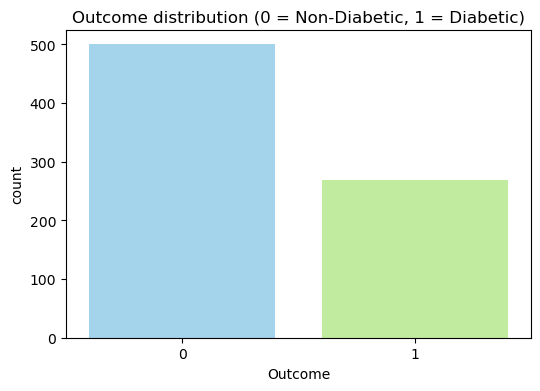

In [298]:
# Check target class balance
print("\nClass counts:\n", df['Outcome'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df,palette = ["#98d6f8", "#bff793"]  )
plt.title("Outcome distribution (0 = Non-Diabetic, 1 = Diabetic)")
plt.show()

In [299]:
# Show missing / zeros logic
print("\nCount of zeros in selected cols:")
cols_with_invalid_zeros = ["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
print(df[cols_with_invalid_zeros].eq(0).sum())



Count of zeros in selected cols:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [300]:
# selective replacement
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, pd.NA)

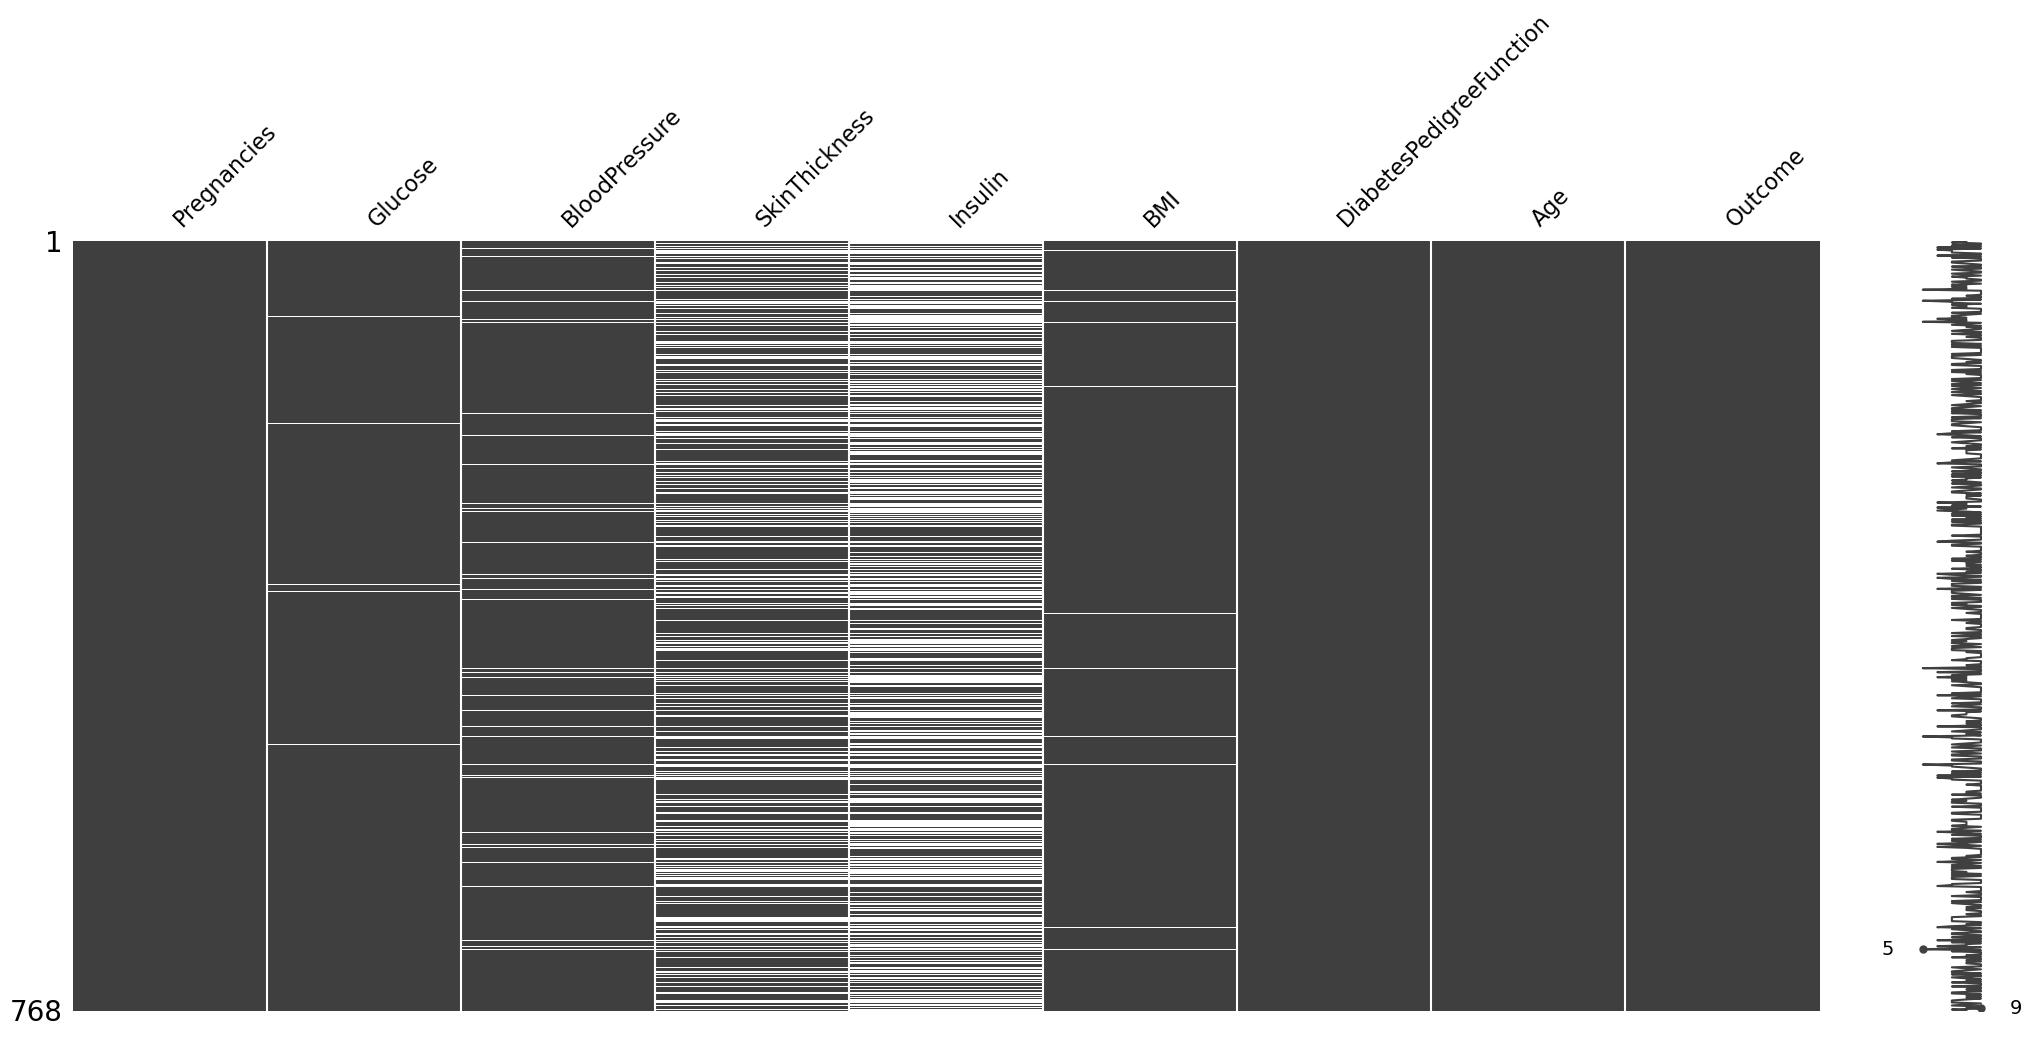

In [301]:
# Visualize missing data
msno.matrix(df)
plt.show()

In [302]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

**Notes:**

- Class Balance:

Dataset is imbalanced: more non-diabetic (0) than diabetic (1).

Suggest using F1-score or ROC-AUC instead of accuracy alone.

- Zeros in Features:

Columns like Glucose, BloodPressure, SkinThickness, Insulin, BMI have many zeros likely placeholders, not real values.

These need to be handled (e.g., replaced with median).

- Missing Data Visualization:

Missing values appear where zeros were replaced , data cleaning is necessary before modeling.

- Duplicates:

Dataset has no significant duplicates.

---

### Phase 2: Preprocessing

In [303]:
# Fill missing values with median
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].fillna(df[cols_with_invalid_zeros].median())

In [304]:
# Save clean version
df.to_csv("diabetes_clean.csv", index=False)

print("✅ Clean dataset saved as 'diabetes_clean.csv'")

✅ Clean dataset saved as 'diabetes_clean.csv'


#### Visualizations

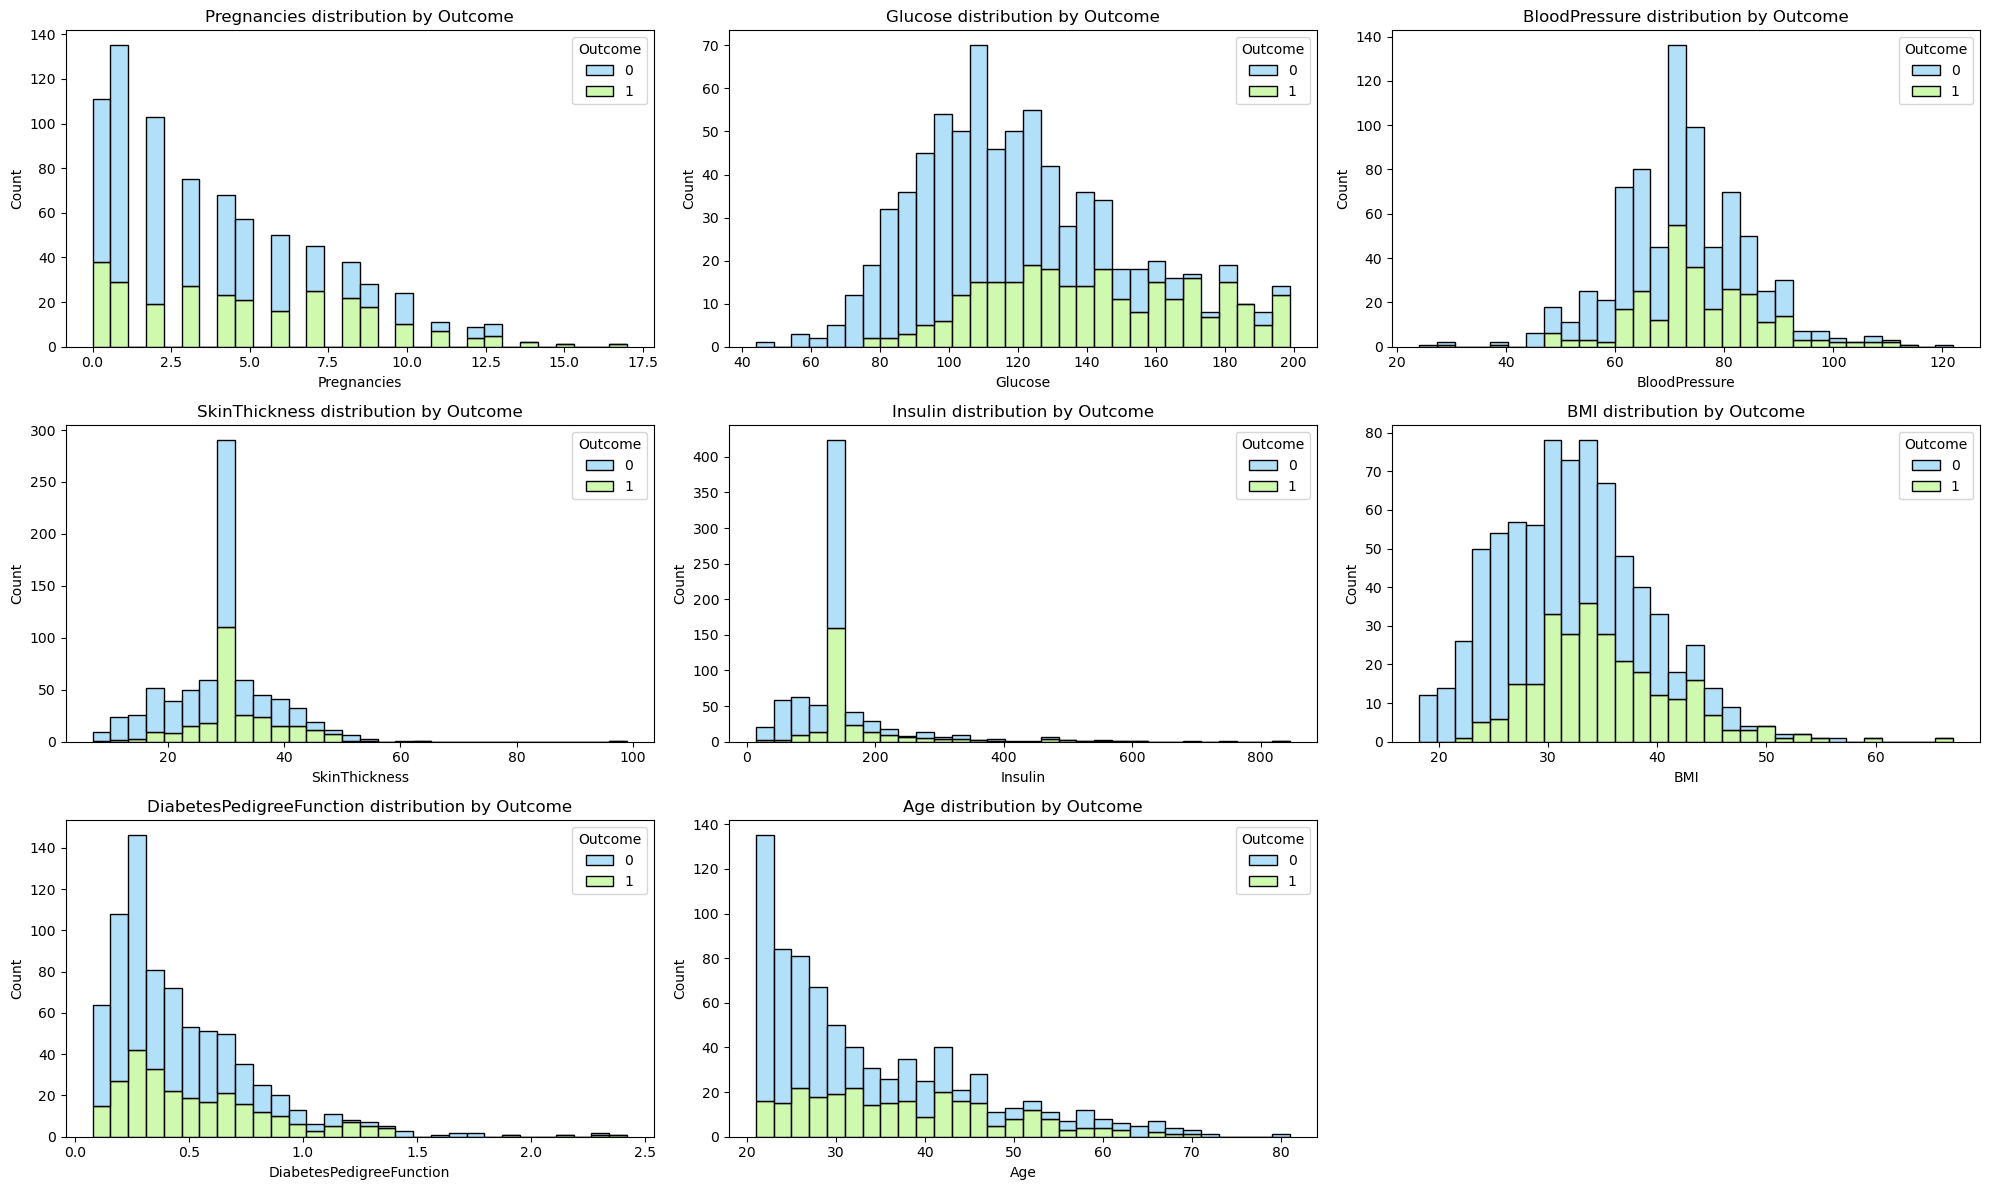

In [305]:
features = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]

plt.figure(figsize=(20,12))

for i, col in enumerate(features, 1):
    plt.subplot(3, 3, i)  
    sns.histplot(data=df, x=col, hue="Outcome", multiple="stack", palette=["#98d6f8", "#bff793"], bins=30)
    plt.title(f"{col} distribution by Outcome")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


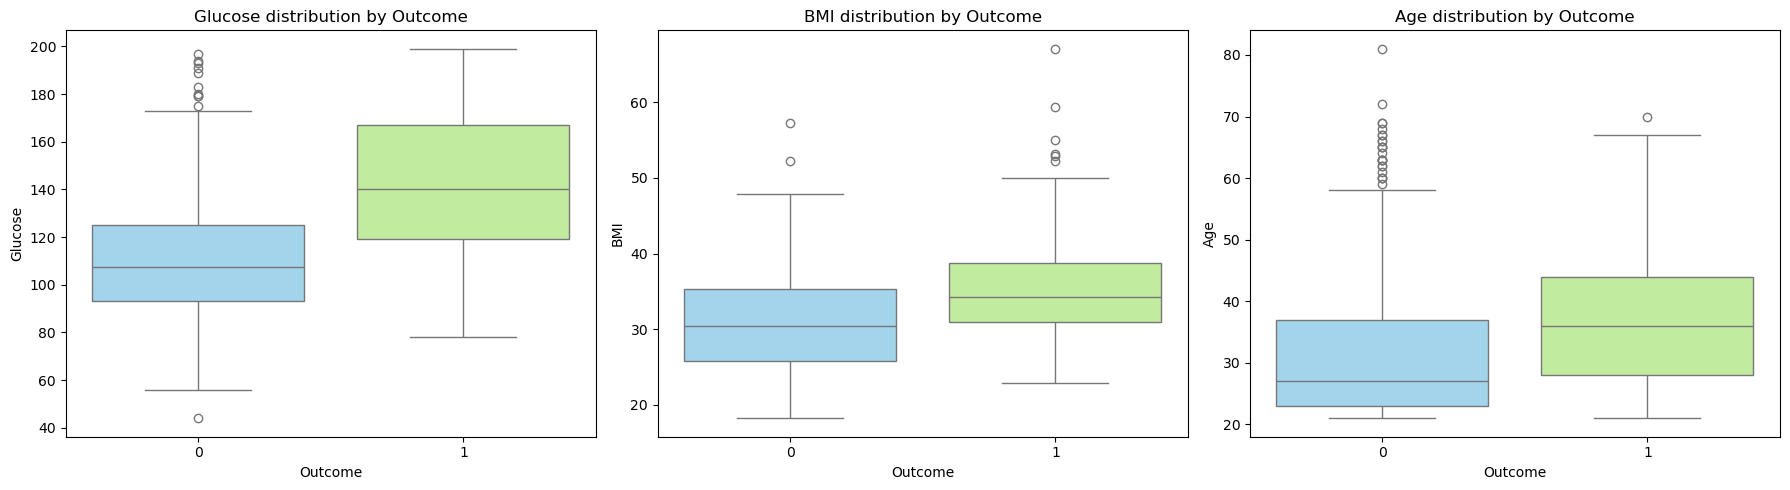

In [306]:
# Boxplots for key features by Outcome
features = ["Glucose", "BMI", "Age"]
fig, axes = plt.subplots(1, 3, figsize=(18,5))  

for ax, col in zip(axes, features):
    sns.boxplot(x="Outcome", y=col, data=df, palette=["#98d6f8", "#bff793"], ax=ax)
    ax.set_title(f"{col} distribution by Outcome")

plt.tight_layout()
plt.show()


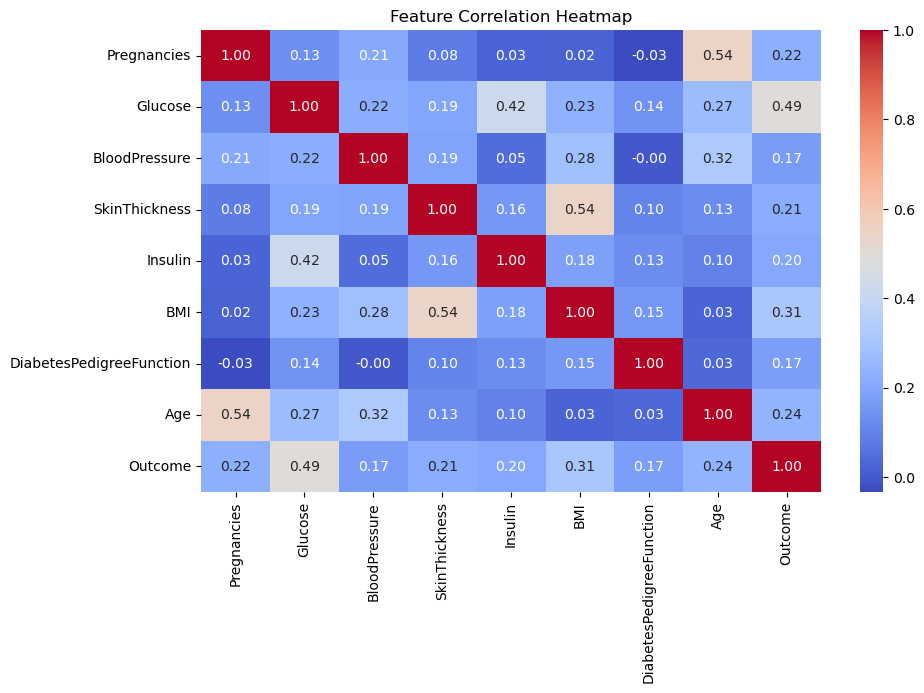

In [307]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [308]:
# Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [309]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [310]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [311]:
# Save scaler for later deployment
joblib.dump(scaler, "models/scaler.pkl")
print("Saved scaler -> models/scaler.pkl")

Saved scaler -> models/scaler.pkl


**Notes:**

- Missing Values: Columns like Glucose, BloodPressure, SkinThickness, Insulin, and BMI had zeros instead of real values. These were replaced with the median.

- Saved Clean Dataset: The cleaned dataset was saved as diabetes_clean.

- Scaling: Features were standardized using StandardScaler to have mean ≈ 0 and std ≈ 1 . Scaler saved for deployment..

- Train/Test Split: Stratified split ensures class distribution is preserved.

- Visualizations: Histograms and boxplots show feature distributions and differences between diabetic and non-diabetic patients. Glucose and BMI are strongly correlated with the outcome.

---

### Phase 3: Modeling

In [312]:
# Define models

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42)
}

# Dictionary to collect results
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-score": f1,
        "ROC-AUC": roc
    })

    # Save each model
    joblib.dump(model, f"models/{name.replace(' ', '_').lower()}.pkl")

# Put results in DataFrame
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"])
print("📊 Model Comparison Results:")
print(results_df)


📊 Model Comparison Results:
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC
0  Logistic Regression  0.707792   0.600000  0.500000  0.545455  0.812963
1        Random Forest  0.740260   0.652174  0.555556  0.600000  0.816111
2              XGBoost  0.759740   0.673469  0.611111  0.640777  0.808148
3                  SVM  0.740260   0.652174  0.555556  0.600000  0.796389


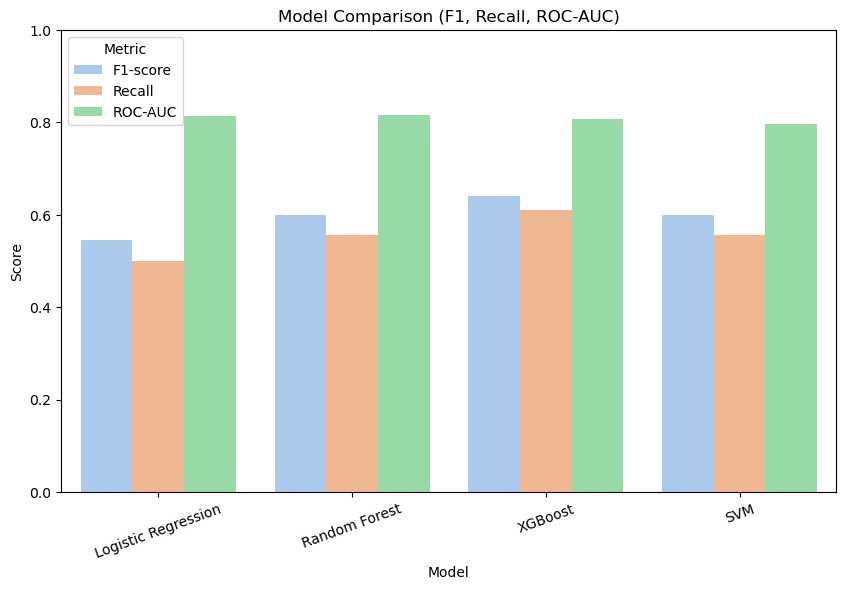

In [313]:
# Plot comparison of F1, Recall, ROC
metrics_to_plot = ["F1-score", "Recall", "ROC-AUC"]
plt.figure(figsize=(10,6))
results_melted = results_df.melt(id_vars="Model", value_vars=metrics_to_plot, var_name="Metric", value_name="Score")
sns.barplot(x="Model", y="Score", hue="Metric", data=results_melted, palette="pastel")
plt.title("Model Comparison (F1, Recall, ROC-AUC)")
plt.xticks(rotation=20)
plt.ylim(0,1)
plt.show()

In [314]:
# Pick best model based on F1-score (or ROC-AUC as secondary)
best_model_name = results_df.sort_values(by=["F1-score", "ROC-AUC"], ascending=False).iloc[0]["Model"]
print(f"Best Model Selected: {best_model_name}")


Best Model Selected: XGBoost


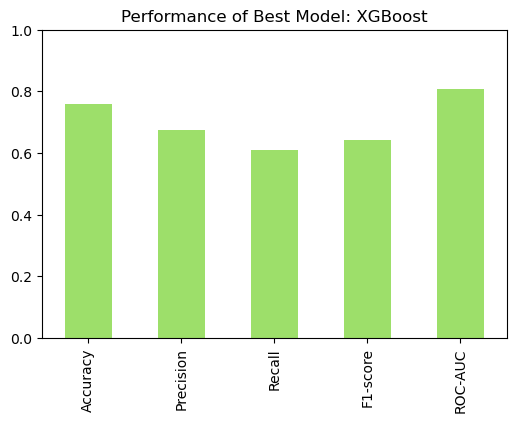

In [315]:
# Plot only best model metrics
best_row = results_df[results_df["Model"] == best_model_name].set_index("Model")
best_row.T.plot(kind="bar", legend=False, figsize=(6,4), color= "#9ddf6a")
plt.title(f"Performance of Best Model: {best_model_name}")
plt.ylim(0,1)
plt.show()

**Notes:**

- Model Selection:
Tested multiple models: Logistic Regression, Random Forest, XGBoost, and SVM.

- Evaluation Metrics:
Used multiple metrics (F1-score, Recall, ROC-AUC) instead of accuracy alone due to class imbalance.

- Model Comparison:
XGBoost performs best across F1, Recall, and ROC-AUC.

- Saving Models:
Each trained model was saved for future deployment.

- Visual Insights:
Bar plots help compare models on multiple metrics simultaneously.

- Best Model Selection:
The model with the highest F1-score (and secondary ROC-AUC) is chosen for deployment.

---

### Phase 4: Prediction function

In [316]:
scaler = joblib.load("models/scaler.pkl")
best_model = joblib.load(f"models/{best_model_name.replace(' ', '_').lower()}.pkl")

def predict_patient(patient_dict):
    """
    Input: patient_dict with keys:
      Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
    Output: (label_str, probability)
    """
    # Ensure correct column order
    cols = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"]
    Xnew = pd.DataFrame([patient_dict], columns=cols)
    Xnew_scaled = scaler.transform(Xnew)
    pred = best_model.predict(Xnew_scaled)[0]
    prob = best_model.predict_proba(Xnew_scaled)[0,1]
    return ("Diabetic" if pred==1 else "Non-Diabetic", float(prob))



Final Insights:

- Data & Preprocessing: Replaced unrealistic zeros, handled missing values, scaled features.

- Modeling: Tested multiple models; XGBoost performed best.

- Deployment: Saved best model and scaler; prediction function ready.

---